In [2]:
import librosa as lr

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from IPython.display import Audio

In [6]:
sample_path = 'sample.wav'

In [7]:
y, sr = lr.load(sample_path, sr=None)

In [8]:
Audio(y, rate=sr)

In [9]:
pitch_up = lr.effects.pitch_shift(y, sr=sr, n_steps=-12)

In [10]:
Audio(pitch_up, rate=sr)

In [11]:
stretch = lr.effects.time_stretch(y, rate=0.5)

In [12]:
Audio(stretch, rate=sr)

In [13]:
stft = lr.stft(y)
db = lr.amplitude_to_db(np.abs(stft), ref=np.max)

/home/arjun/.local/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/arjun/.local/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


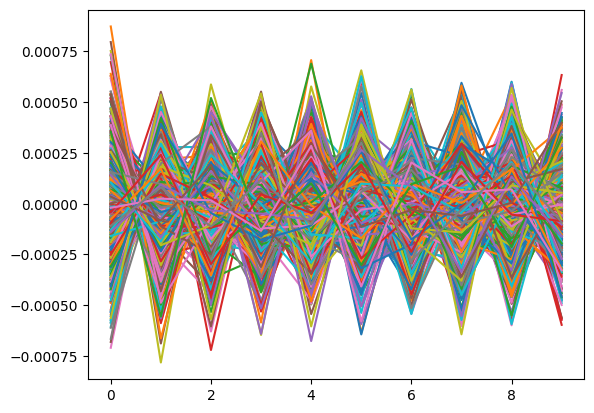

In [14]:
plt.plot(stft[0:10])

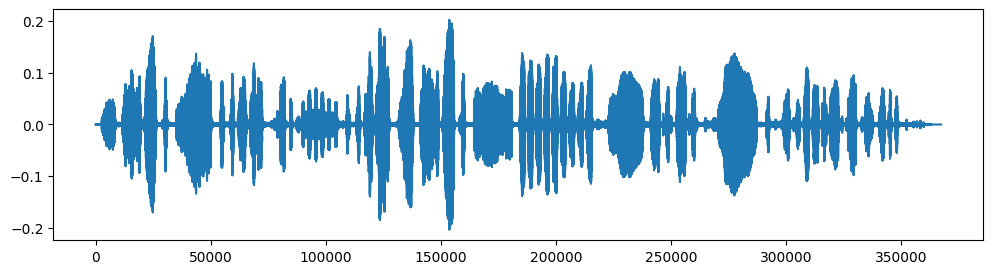

In [15]:
plt.figure(figsize=(12, 3))
plt.plot(y)

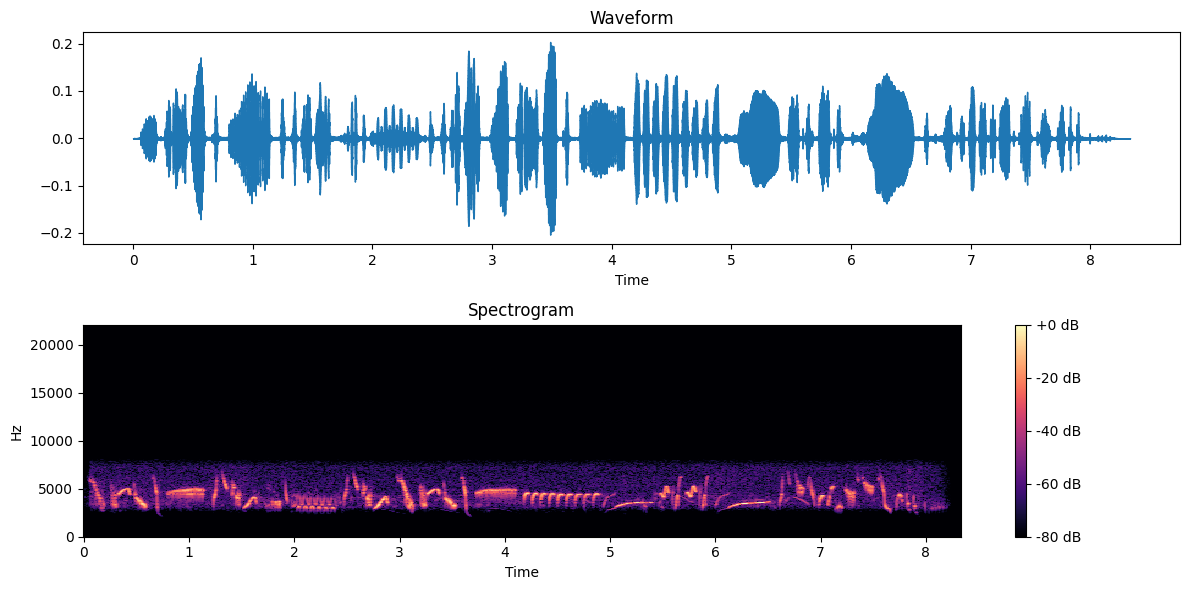

In [16]:
# Plot waveform and spectrogram
plt.figure(figsize=(12, 6))

# Waveform
plt.subplot(2, 1, 1)
lr.display.waveshow(y, sr=sr)
plt.title("Waveform")

# Spectrogram
plt.subplot(2, 1, 2)
lr.display.specshow(db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")

plt.tight_layout()
plt.show()

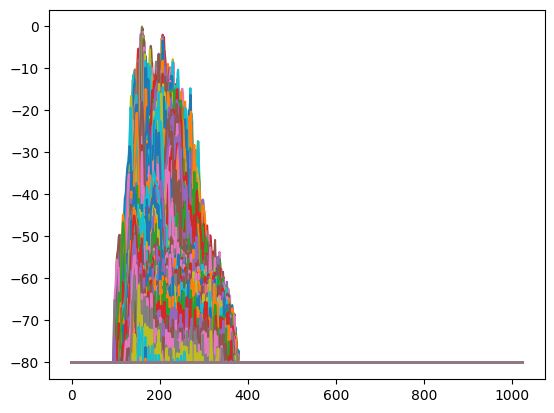

In [17]:
plt.plot(db)
plt.show()

In [18]:
db.shape

(1025, 718)

In [19]:
db

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(1025, 718), dtype=float32)

In [20]:
stft.shape

(1025, 718)

In [21]:
y.shape

(367457,)

In [22]:
Audio(stft[580,:], rate=sr)

/home/arjun/.local/lib/python3.12/site-packages/IPython/lib/display.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  data = np.array(data, dtype=float)


In [25]:
dec = lr.decompose.nn_filter(db,  aggregate=np.median, metric='cosine')

In [26]:
dec

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(1025, 718), dtype=float32)

In [27]:
diff = np.abs(db - dec)
print("Mean difference:", diff.mean())

Mean difference: 1.2201499


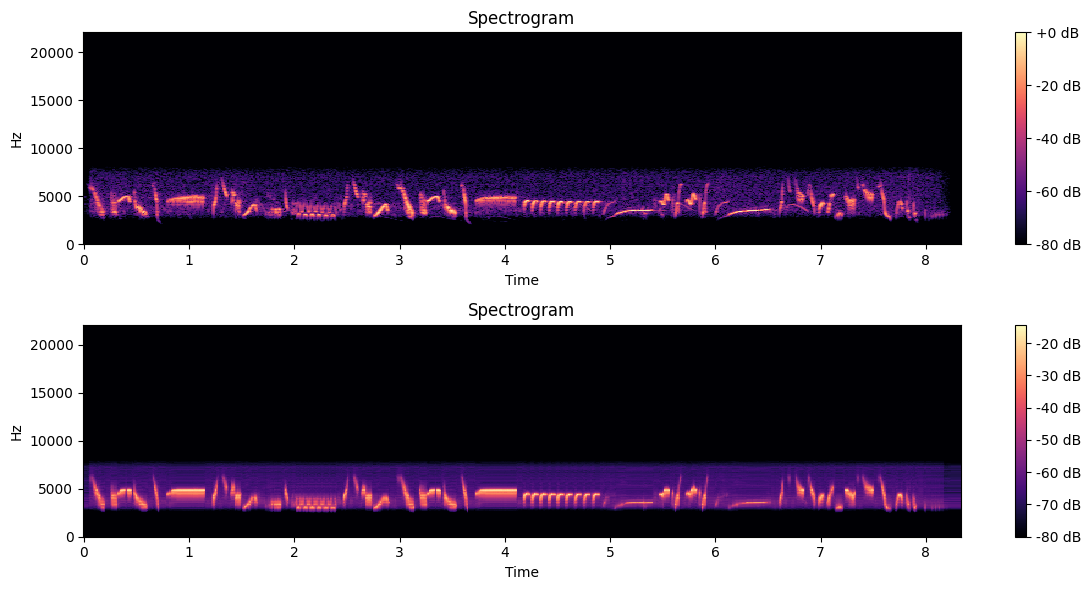

In [30]:
plt.figure(figsize=(12,6))

plt.subplot(2, 1, 1)
lr.display.specshow(db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")

plt.subplot(2, 1, 2)
lr.display.specshow(dec, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")

plt.tight_layout()
plt.show()

In [38]:
b = lr.db_to_amplitude(dec)
s = b * np.exp(1) * np.angle(stft)
na = lr.istft(s)

In [43]:
Audio(y, rate=sr)

In [41]:
Audio(na, rate=sr)

In [39]:
na

array([-3.76300659e-06,  8.42169895e-07,  1.90186763e-06, ...,
       -3.66583729e-05,  2.96982969e-05,  3.09702754e-05], shape=(367104,))

In [40]:
y

array([ 1.5258789e-05,  0.0000000e+00,  0.0000000e+00, ...,
        0.0000000e+00, -1.5258789e-05, -1.5258789e-05],
      shape=(367457,), dtype=float32)